**Determining Fluorescence of Genetically Encoded Calcium Indicators (GECIs) Relative to Light Brightness Levels**

***How to predict Fluorescence levels of GECIs relative to the brightness of laser light.***

*How does this work?*

*A hills function exponential decay regression model is fitted to collected light intensity and fluorescence data for the following GECIs.*

The following GECIs can be modeled in the program:
GCAMP6f, GCAMP6s
GCAMP7b, GCAMP7c, GCAMP7f, GCAMP7s
XGCAMPgf, GCAMP3, OGB-1, GCAMP6f-RS06, GCAMP6f-RS09

The code works by setting up the model to collect information to model neuronal activity. It creates a series of spikes and assigns them to specific light aggregator neuron indices.

***Setup***

In [208]:
from cleo.imaging import sensors
from cleo.utilities import brian_safe_name
from cleo.ioproc import RecordOnlyProcessor
import cleo
import pandas as pd
import numpy as np
import brian2 as b2
from pathlib import Path

b2.defaultclock = 0.1 * b2.ms

i_spike_bound = 3
n_spk = 10
n_rns = 5
rng = np.random.default_rng(49)
t_spk = 40 * rng.random((n_spk,)) * b2.ms
i_spk = rng.choice(range(i_spike_bound), n_spk)

Then a spike generator group injects predefined spikes into the neurons, which is then wrapped inside of a CLEO group to help with optogenetic stimulation, imaging sensors, and closed-loop control.

In [209]:
sgg = b2.SpikeGeneratorGroup(n_rns, i_spk, t_spk)
sgg._N = n_rns
sim = cleo.CLSimulator(b2.Network(sgg))
processor = RecordOnlyProcessor(sample_period = 1.0 * b2.ms)
sim.set_io_processor(processor)
script_dir = Path.cwd()
target_file = script_dir.parent.parent / "cleo" / "imaging" / "gecis.csv"

Then it loads the parameters for a specific GECI, which helps create a sensor model function that then helps to create a GECI gcamp sensor. Afterwards, there is a calcium sensor attached to the gcamp so that the spikes and calcium dynamics and fluorescence that they cause can be registered and viewed later on.

In [210]:

df = pd.read_csv(target_file)
row = df.iloc[1]
sensors._create_geci_fn(row.iloc[0], **row.iloc[6:-2])
sensor_name = brian_safe_name(row.iloc[0].lower())
geci_factory = sensors.__dict__[sensor_name]
gcamp = geci_factory()
if (gcamp is None):
    print("gcamp is None")
elif not hasattr(gcamp, 'sim'):
    gcamp.sim = None
    print("gcamp has no sim object")

In [211]:
monitor = b2.StateMonitor(gcamp.sim, sgg.name, record=True)
sim.network.add(monitor)

AttributeError: 'NoneType' object has no attribute 'clock'

Finally the simulation is run and the output is collected and outputed for the experimenter to see.

In [ ]:
sim.inject(gcamp, sgg, 'euler')
sim.run(50 * b2.ms)
dFF = gcamp.get_state()[sgg.name]

WARNING    The object 'networkoperation' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cleo/base.py', line 505, in set_io_processor
    self._processing_net_op = NetworkOperation( [brian2.core.base.unused_brian_object]
WARNING    The object 'networkoperation_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cleo/base.py', line 505, in set_io_processor
    self._processing_net_op = NetworkOperation( [brian2.core.base

In [ ]:
print(f"dFF is: {dFF}")
print(f"processor.t_samp is: {processor.t_samp}")
print(f"processor.out_buffer is: {processor.out_buffer}")
print(f"gcamp.variables.keys() is: {list(gcamp.variables.keys())}")

dFF is: <syn_jgcamp3_spikegeneratorgroup_5.dFF: array([0.00088953, 0.00065527, 0.00070686, 0.        , 0.        ])>
processor.t_samp is: [] s
processor.out_buffer is: deque([])


AttributeError: 'GECI' object has no attribute 'group'

Here is a plot of the fluorescence across all of the neurons and a second plot of the gcamp's response to spikes.

AttributeError: 'RecordOnlyProcessor' object has no attribute 't_ms'

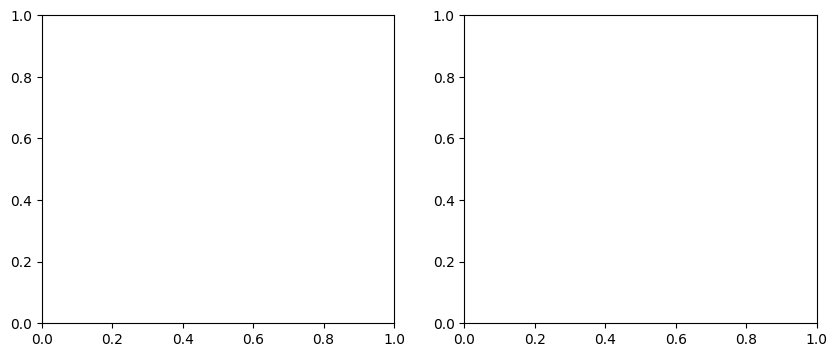

In [ ]:
import matplotlib.pyplot as plt

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw = {'width_ratios' : [1, 1]})
t = np.arange(0, n_rns, 1)
ax1.plot(processor.t_ms, processor.values, label='dF/F', color='green')
ax2.stem(t_spk/b2.ms, [1.1] * len(t_spk), linefmt='r', markerfmt='ro', basefmt='', label='Spikes')
ax2.set(xlabel='Time (ms)', ylabel='dF/F', title='GECI Response to Spikes')
ax2.legend()
plt.show()

So, essentially, the program requires that you must first specify the specific genetically encoded calcium indicator (GECI) that you want to use followed by the parameters that you want to include for calcium fluxes and fluorescent responses. Then the spike generator group injects a current with a specific wavelength and brightness that the light aggregator neuron can use to formulate the fluorescent values. 

The relationship between the GECI's brightness and normalized fluorescence values comes from creating a hills function exponential decay model to relating the brightness levels to the normalized fluorescence level.

Here is an example of how this regression model fits the data for the jgcamp7c GECI for brightness and normalized fluorescence level.

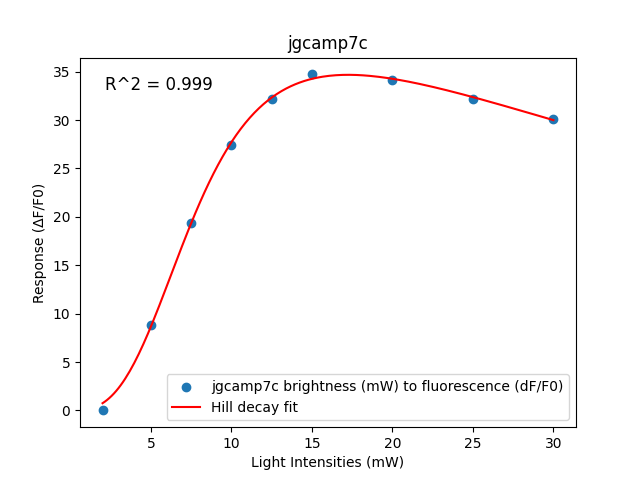

For wavelength relative to the fluorescence level the data on wavelength and normalized fluorescence is collected and then interpolated.

The interpolation function's values from the given wavelength and brightness are then taken and multiplied together to generate the predicted normalized fluorescence values.